In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import string
import warnings
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, classification_report, confusion_matrix)
warnings.filterwarnings('ignore')


In [3]:
df = pd.read_csv("language.csv")
print(df.shape)
print(df.head())


(22000, 2)
                                                Text  language
0  klement gottwaldi surnukeha palsameeriti ning ...  Estonian
1  sebes joseph pereira thomas  på eng the jesuit...   Swedish
2  ถนนเจริญกรุง อักษรโรมัน thanon charoen krung เ...      Thai
3  விசாகப்பட்டினம் தமிழ்ச்சங்கத்தை இந்துப் பத்திர...     Tamil
4  de spons behoort tot het geslacht haliclona en...     Dutch


In [4]:
df.isnull().sum()

Text        0
language    0
dtype: int64

In [5]:
df['language'].value_counts()

language
Estonian      1000
Swedish       1000
English       1000
Russian       1000
Romanian      1000
Persian       1000
Pushto        1000
Spanish       1000
Hindi         1000
Korean        1000
Chinese       1000
French        1000
Portugese     1000
Indonesian    1000
Urdu          1000
Latin         1000
Turkish       1000
Japanese      1000
Dutch         1000
Tamil         1000
Thai          1000
Arabic        1000
Name: count, dtype: int64

In [6]:
df.dtypes

Text        object
language    object
dtype: object

## EDA – Exploratory Data Analysis and Feature Engineering

In [7]:
df['char_count']      = df['Text'].apply(len)
df['word_count']      = df['Text'].apply(lambda x: len(x.split()))
df['avg_word_len']    = df['Text'].apply(lambda x: np.mean([len(w) for w in x.split()]) if x.split() else 0)
df['digit_count']     = df['Text'].apply(lambda x: sum(c.isdigit() for c in x))
df['upper_count']     = df['Text'].apply(lambda x: sum(c.isupper() for c in x))
df['lower_count']     = df['Text'].apply(lambda x: sum(c.islower() for c in x))
df['punct_count']     = df['Text'].apply(lambda x: sum(1 for c in x if c in string.punctuation))
df['unique_chars']    = df['Text'].apply(lambda x: len(set(x)))
df['first_cap']       = df['Text'].apply(lambda x: x[0].isupper() if x else False)
df['ends_punct']      = df['Text'].apply(lambda x: x[-1] in string.punctuation if x else False)
df['vowel_count']     = df['Text'].apply(lambda x: sum(c.lower() in 'aeiou' for c in x))
df['consonant_count'] = df['Text'].apply(lambda x: sum(c.lower() in 'bcdfghjklmnpqrstvwxyz' for c in x))
df['space_count']     = df['Text'].apply(lambda x: x.count(' '))
print(df[['char_count','word_count','avg_word_len']].head())


   char_count  word_count  avg_word_len
0         339          45      6.533333
1         171          27      5.185185
2         251          14     17.000000
3         305          28      9.857143
4         176          28      5.285714


## Text Preprocessing

In [8]:
def clean_text(text):
    text = text.lower()
    text = ''.join([char for char in text if char not in string.punctuation])
    return text

df['Text'] = df['Text'].apply(clean_text)
print("Cleaned sample:", df['Text'].iloc[0][:100])


Cleaned sample: klement gottwaldi surnukeha palsameeriti ning paigutati mausoleumi surnukeha oli aga liiga hilja ja 


## Train / Test Split

In [9]:
X = df['Text']
y = df['language']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y)

print("Train size:", X_train.shape[0])
print("Test  size:", X_test.shape[0])


Train size: 17600
Test  size: 4400


In [10]:
# Bag-of-Words (for Naive Bayes)
bow_vectorizer = CountVectorizer()
X_train_bow = bow_vectorizer.fit_transform(X_train)
X_test_bow  = bow_vectorizer.transform(X_test)

# TF-IDF with character n-grams (for LR, SVM, RF)
tfidf_vectorizer = TfidfVectorizer(analyzer='char', ngram_range=(1, 3), max_features=50000)
X_train_tfidf = tfidf_vectorizer.fit_transform(X_train)
X_test_tfidf  = tfidf_vectorizer.transform(X_test)

# TF-IDF word-level limited (for Random Forest — dense-friendly)
tfidf_rf = TfidfVectorizer(max_features=1000)
X_train_rf = tfidf_rf.fit_transform(X_train)
X_test_rf  = tfidf_rf.transform(X_test)

label_encoder = LabelEncoder()
label_encoder.fit(y)
print("Vectorisers ready.")


Vectorisers ready.


## Multinomial Naive Bayes Model

In [11]:
nb_model = MultinomialNB()
nb_model.fit(X_train_bow, y_train)

y_pred_train_nb = nb_model.predict(X_train_bow)
print(y_pred_train_nb)
y_pred_nb       = nb_model.predict(X_test_bow)
print(y_pred_nb)

train_accuracy_nb = accuracy_score(y_train, y_pred_train_nb)
accuracy_nb       = accuracy_score(y_test,  y_pred_nb)
precision_nb      = precision_score(y_test, y_pred_nb, average='macro', zero_division=1)
recall_nb         = recall_score(y_test,    y_pred_nb, average='macro', zero_division=1)
f1_nb             = f1_score(y_test,        y_pred_nb, average='macro', zero_division=1)

print("Training Accuracy:", train_accuracy_nb)
print("Test Accuracy    :", accuracy_nb)
print("Precision        :", precision_nb)
print("Recall           :", recall_nb)
print("F1 Score         :", f1_nb)


['Romanian' 'Spanish' 'Spanish' ... 'Russian' 'Portugese' 'Russian']
['Persian' 'Spanish' 'Tamil' ... 'Dutch' 'Latin' 'Latin']
Training Accuracy: 0.984375
Test Accuracy    : 0.9427272727272727
Precision        : 0.9579289142792391
Recall           : 0.9427272727272725
F1 Score         : 0.9424447677611031


In [12]:
print(classification_report(y_test, y_pred_nb))

              precision    recall  f1-score   support

      Arabic       0.63      1.00      0.78       200
     Chinese       0.95      0.54      0.69       200
       Dutch       0.99      0.98      0.98       200
     English       0.68      1.00      0.81       200
    Estonian       1.00      0.96      0.98       200
      French       0.94      0.99      0.97       200
       Hindi       0.99      0.96      0.98       200
  Indonesian       0.99      0.97      0.98       200
    Japanese       0.98      0.61      0.76       200
      Korean       1.00      0.97      0.99       200
       Latin       0.99      0.93      0.96       200
     Persian       1.00      0.99      0.99       200
   Portugese       0.98      0.95      0.97       200
      Pushto       1.00      0.96      0.98       200
    Romanian       0.99      0.98      0.99       200
     Russian       0.99      0.99      0.99       200
     Spanish       0.98      0.98      0.98       200
     Swedish       0.99    

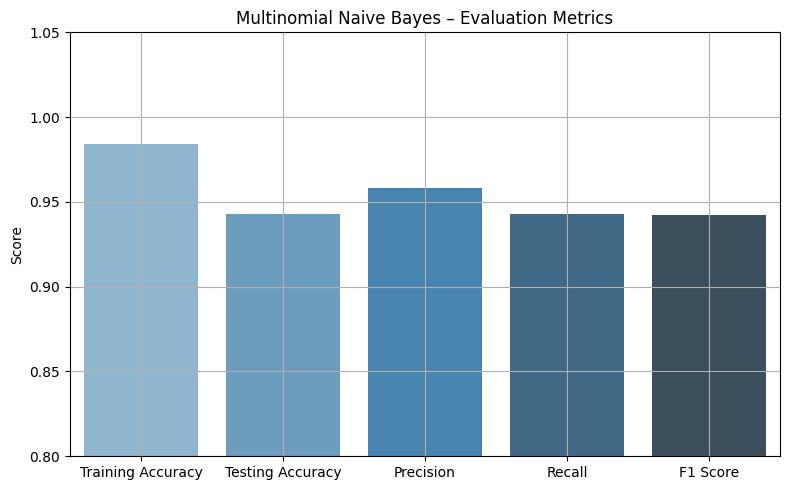

In [13]:
metrics_nb = ['Training Accuracy', 'Testing Accuracy', 'Precision', 'Recall', 'F1 Score']
values_nb  = [train_accuracy_nb, accuracy_nb, precision_nb, recall_nb, f1_nb]

plt.figure(figsize=(8, 5))
sns.barplot(x=metrics_nb, y=values_nb, palette='Blues_d')
plt.title('Multinomial Naive Bayes – Evaluation Metrics')
plt.ylim(0.8, 1.05)
plt.ylabel('Score')
plt.grid(True)
plt.tight_layout()
plt.show()


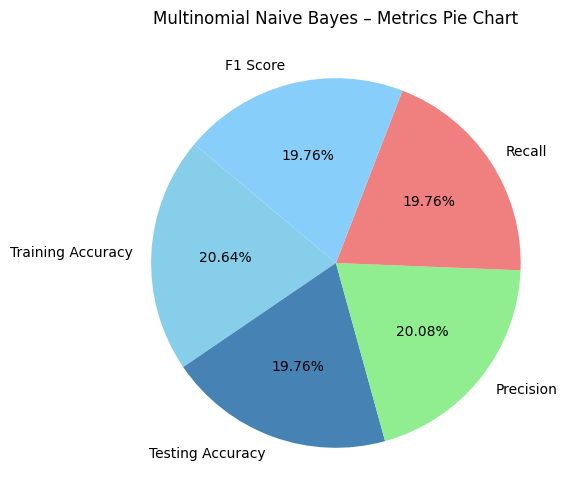

In [14]:
plt.figure(figsize=(6, 6))
plt.pie(values_nb, labels=metrics_nb, autopct='%1.2f%%', startangle=140,
        colors=['skyblue','steelblue','lightgreen','lightcoral','lightskyblue'])
plt.title('Multinomial Naive Bayes – Metrics Pie Chart')
plt.show()


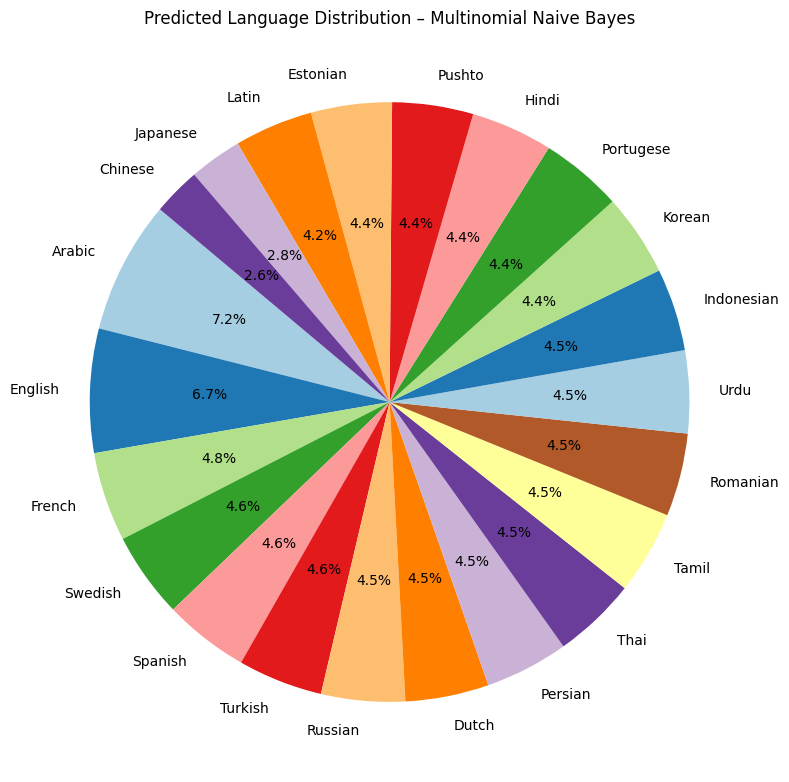

In [15]:
plt.figure(figsize=(8, 8))
pred_counts_nb = pd.Series(y_pred_nb).value_counts()
plt.pie(pred_counts_nb, labels=pred_counts_nb.index, autopct='%1.1f%%',
        startangle=140, colors=plt.cm.Paired.colors)
plt.title('Predicted Language Distribution – Multinomial Naive Bayes')
plt.axis('equal')
plt.tight_layout()
plt.show()


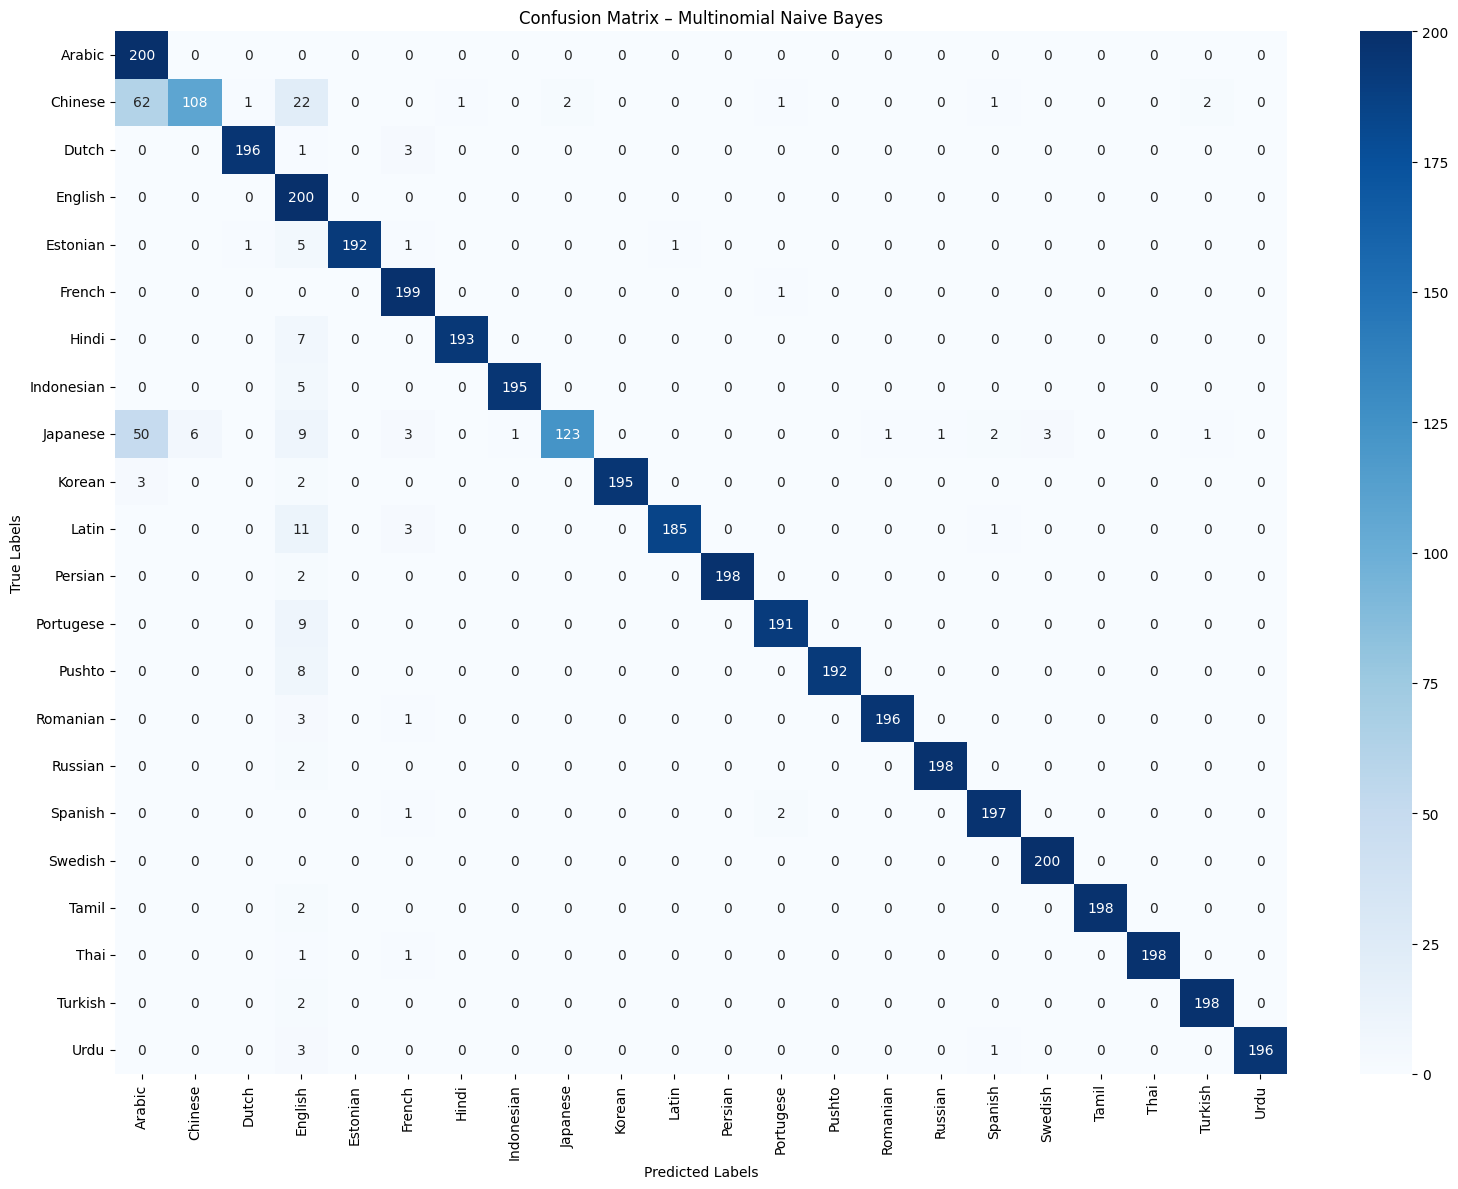

In [16]:
cm_nb = confusion_matrix(y_test, y_pred_nb, labels=label_encoder.classes_)
plt.figure(figsize=(16, 12))
sns.heatmap(cm_nb, annot=True, fmt='d', cmap='Blues',
            xticklabels=label_encoder.classes_,
            yticklabels=label_encoder.classes_)
plt.title('Confusion Matrix – Multinomial Naive Bayes')
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.xticks(rotation=90); plt.yticks(rotation=0)
plt.tight_layout()
plt.show()


In [17]:
def predict_language_naive_bayes(input_text):
    cleaned_text = clean_text(input_text)
    input_vector = bow_vectorizer.transform([cleaned_text])
    prediction = nb_model.predict(input_vector)[0]
    print("\nInput Text:", input_text)
    print("Predicted Language (Naive Bayes):", prediction)

while True:
    user_input = input("\n[Multinomial Naive Bayes] Enter a sentence to detect its language (type 'exit' to stop): ")
    if user_input.lower() == 'exit':
        print("Exiting Naive Bayes testing.")
        break
    predict_language_naive_bayes(user_input)


[Multinomial Naive Bayes] Enter a sentence to detect its language (type 'exit' to stop):  My name is Abhishek



Input Text: My name is Abhishek
Predicted Language (Naive Bayes): English



[Multinomial Naive Bayes] Enter a sentence to detect its language (type 'exit' to stop):  exit


Exiting Naive Bayes testing.


## Logistic Regression Model

In [18]:
lr_model = LogisticRegression(max_iter=1000, solver='lbfgs', multi_class='multinomial')
lr_model.fit(X_train_tfidf, y_train)

y_pred_train_lr = lr_model.predict(X_train_tfidf)
print(y_pred_train_lr)
y_pred_lr       = lr_model.predict(X_test_tfidf)
print(y_pred_lr)
train_accuracy_lr = accuracy_score(y_train, y_pred_train_lr)
accuracy_lr       = accuracy_score(y_test,  y_pred_lr)
precision_lr      = precision_score(y_test, y_pred_lr, average='macro', zero_division=1)
recall_lr         = recall_score(y_test,    y_pred_lr, average='macro', zero_division=1)
f1_lr             = f1_score(y_test,        y_pred_lr, average='macro', zero_division=1)

print("Training Accuracy:", train_accuracy_lr)
print("Test Accuracy    :", accuracy_lr)
print("Precision        :", precision_lr)
print("Recall           :", recall_lr)
print("F1 Score         :", f1_lr)


['Romanian' 'Spanish' 'Spanish' ... 'Russian' 'Latin' 'Russian']
['Persian' 'Spanish' 'Tamil' ... 'Dutch' 'Latin' 'Latin']
Training Accuracy: 0.9845454545454545
Test Accuracy    : 0.9820454545454546
Precision        : 0.9838110174081717
Recall           : 0.9820454545454544
F1 Score         : 0.9824670750882226


In [19]:
print(classification_report(y_test, y_pred_lr))

              precision    recall  f1-score   support

      Arabic       1.00      1.00      1.00       200
     Chinese       0.99      0.99      0.99       200
       Dutch       0.97      0.98      0.98       200
     English       0.82      0.99      0.90       200
    Estonian       0.99      0.97      0.98       200
      French       0.96      0.99      0.98       200
       Hindi       1.00      0.96      0.98       200
  Indonesian       0.99      0.97      0.98       200
    Japanese       1.00      0.99      0.99       200
      Korean       1.00      0.99      0.99       200
       Latin       0.95      0.94      0.94       200
     Persian       0.99      0.99      0.99       200
   Portugese       0.99      0.97      0.98       200
      Pushto       1.00      0.95      0.97       200
    Romanian       1.00      0.98      0.99       200
     Russian       0.99      0.99      0.99       200
     Spanish       0.99      0.98      0.99       200
     Swedish       1.00    

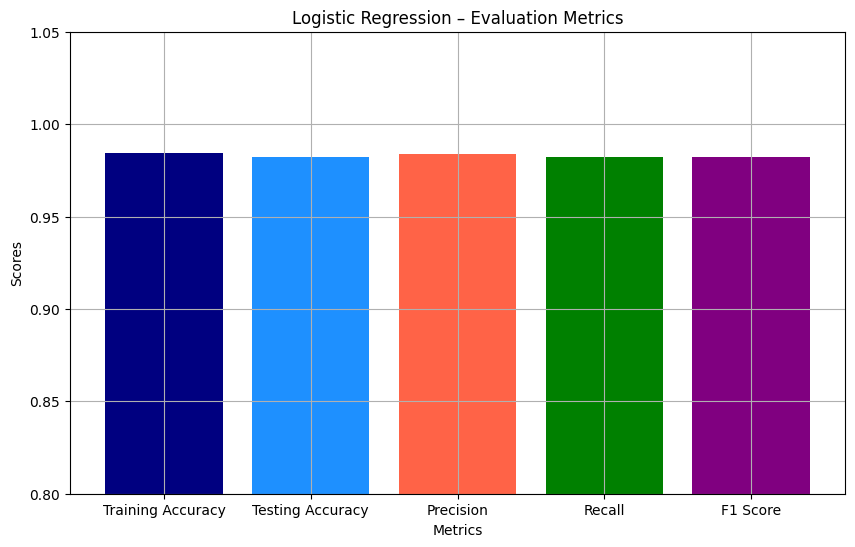

In [20]:
metrics_lr = ['Training Accuracy', 'Testing Accuracy', 'Precision', 'Recall', 'F1 Score']
values_lr  = [train_accuracy_lr, accuracy_lr, precision_lr, recall_lr, f1_lr]

plt.figure(figsize=(10, 6))
plt.bar(metrics_lr, values_lr, color=['navy','dodgerblue','tomato','green','purple'])
plt.title('Logistic Regression – Evaluation Metrics')
plt.ylabel('Scores'); plt.xlabel('Metrics')
plt.ylim(0.8, 1.05); plt.grid(True)
plt.show()


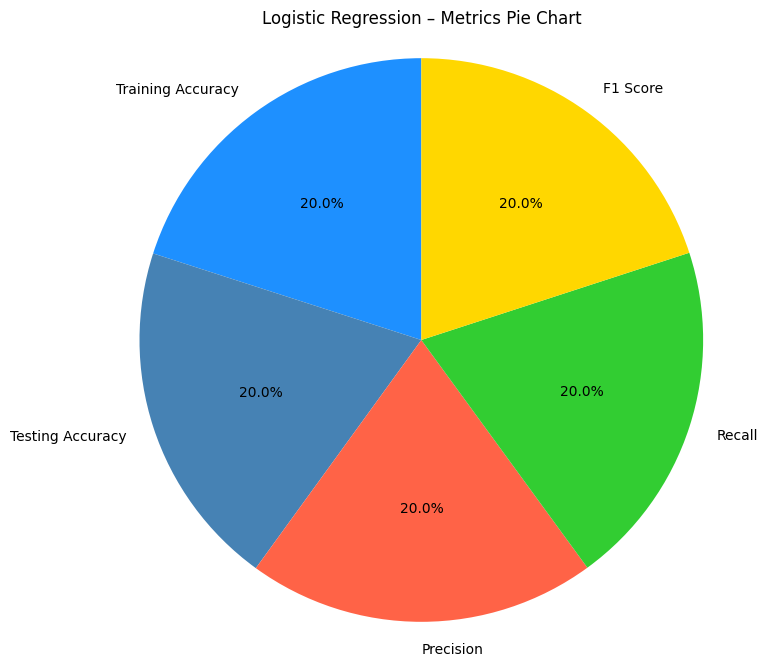

In [21]:
plt.figure(figsize=(8, 8))
colors_lr = ['#1E90FF','#4682B4','#FF6347','#32CD32','#FFD700']
plt.pie(values_lr, labels=metrics_lr, autopct='%1.1f%%', startangle=90, colors=colors_lr)
plt.title('Logistic Regression – Metrics Pie Chart')
plt.axis('equal')
plt.show()


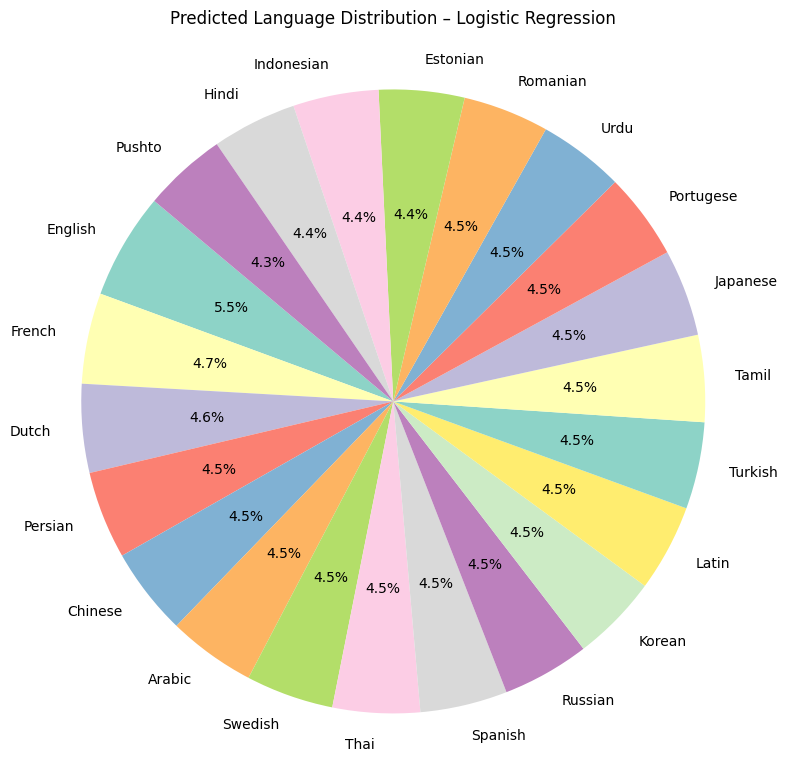

In [22]:
plt.figure(figsize=(8, 8))
pred_counts_lr = pd.Series(y_pred_lr).value_counts()
plt.pie(pred_counts_lr, labels=pred_counts_lr.index, autopct='%1.1f%%',
        startangle=140, colors=plt.cm.Set3.colors)
plt.title('Predicted Language Distribution – Logistic Regression')
plt.axis('equal'); plt.tight_layout()
plt.show()


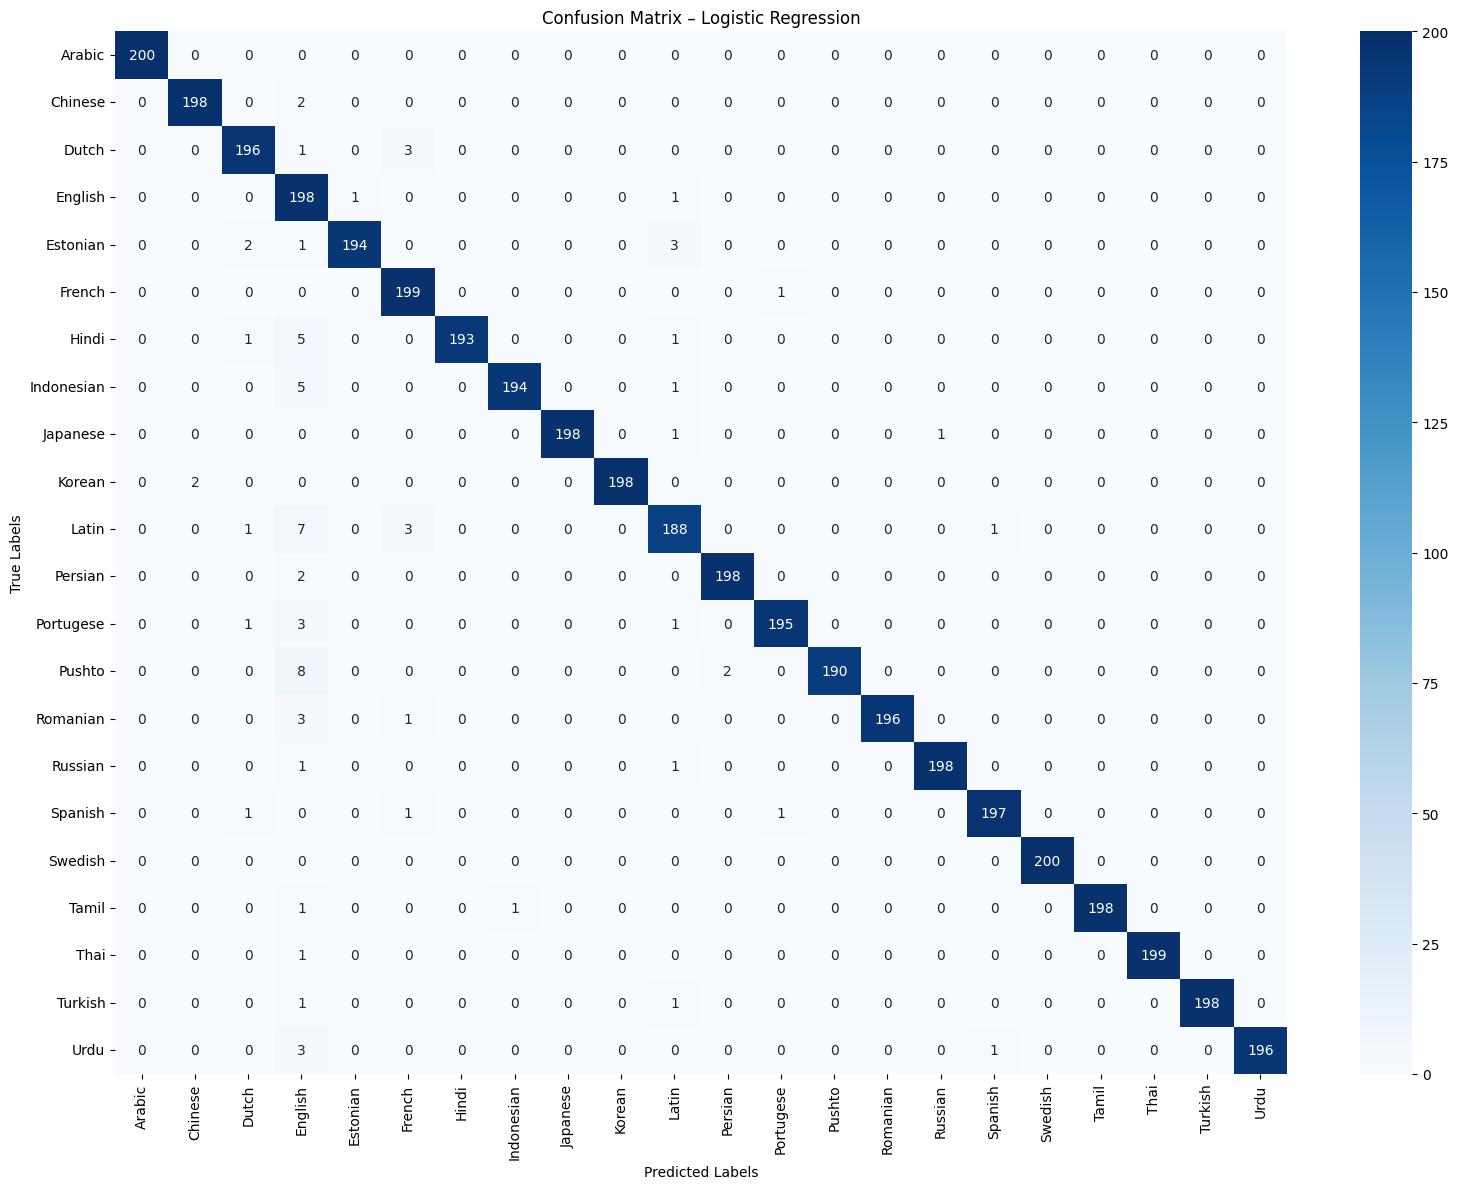

In [23]:
cm_lr = confusion_matrix(y_test, y_pred_lr, labels=label_encoder.classes_)
plt.figure(figsize=(16, 12))
sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Blues',
            xticklabels=label_encoder.classes_,
            yticklabels=label_encoder.classes_)
plt.title('Confusion Matrix – Logistic Regression')
plt.xlabel('Predicted Labels'); plt.ylabel('True Labels')
plt.xticks(rotation=90); plt.yticks(rotation=0)
plt.tight_layout(); plt.show()


In [42]:
def predict_language_logistic_regression(input_text):
    cleaned_text = clean_text(input_text)
    input_vector = tfidf_vectorizer.transform([cleaned_text])
    prediction = lr_model.predict(input_vector)[0]
    print("\nInput Text:", input_text)
    print("Predicted Language (Logistic Regression):", prediction)

while True:
    user_input = input("\n[Logistic Regression] Enter a sentence to detect its language (type 'exit' to stop): ")
    if user_input.lower() == 'exit':
        print("Exiting Logistic Regression testing.")
        break
    predict_language_logistic_regression(user_input)



[Logistic Regression] Enter a sentence to detect its language (type 'exit' to stop):  私の名前はアビシェクです



Input Text: 私の名前はアビシェクです
Predicted Language (Logistic Regression): Japanese



[Logistic Regression] Enter a sentence to detect its language (type 'exit' to stop):  exit


Exiting Logistic Regression testing.


## SVM – Support Vector Machine Model

In [25]:
svm_model = LinearSVC(max_iter=2000)
svm_model.fit(X_train_tfidf, y_train)

y_pred_train_svm = svm_model.predict(X_train_tfidf)
print(y_pred_train_svm)
y_pred_svm       = svm_model.predict(X_test_tfidf)
print(y_pred_svm)
train_accuracy_svm = accuracy_score(y_train, y_pred_train_svm)
accuracy_svm       = accuracy_score(y_test,  y_pred_svm)
precision_svm      = precision_score(y_test, y_pred_svm, average='macro', zero_division=1)
recall_svm         = recall_score(y_test,    y_pred_svm, average='macro', zero_division=1)
f1_svm             = f1_score(y_test,        y_pred_svm, average='macro', zero_division=1)

print("Training Accuracy:", train_accuracy_svm)
print("Test Accuracy    :", accuracy_svm)
print("Precision        :", precision_svm)
print("Recall           :", recall_svm)
print("F1 Score         :", f1_svm)


['Romanian' 'Spanish' 'Spanish' ... 'Russian' 'Portugese' 'Russian']
['Persian' 'Spanish' 'Tamil' ... 'Dutch' 'Latin' 'Latin']
Training Accuracy: 0.9971590909090909
Test Accuracy    : 0.9854545454545455
Precision        : 0.9868012081483012
Recall           : 0.9854545454545455
F1 Score         : 0.985764710782234


In [26]:
print(classification_report(y_test, y_pred_svm))

              precision    recall  f1-score   support

      Arabic       1.00      1.00      1.00       200
     Chinese       0.99      0.99      0.99       200
       Dutch       0.99      0.99      0.99       200
     English       0.84      0.99      0.91       200
    Estonian       1.00      0.99      0.99       200
      French       0.97      0.99      0.98       200
       Hindi       1.00      0.96      0.98       200
  Indonesian       0.99      0.97      0.98       200
    Japanese       1.00      0.99      1.00       200
      Korean       1.00      0.99      1.00       200
       Latin       0.96      0.94      0.95       200
     Persian       1.00      0.99      0.99       200
   Portugese       0.98      0.98      0.98       200
      Pushto       1.00      0.96      0.98       200
    Romanian       1.00      0.98      0.99       200
     Russian       0.99      0.99      0.99       200
     Spanish       0.98      0.98      0.98       200
     Swedish       1.00    

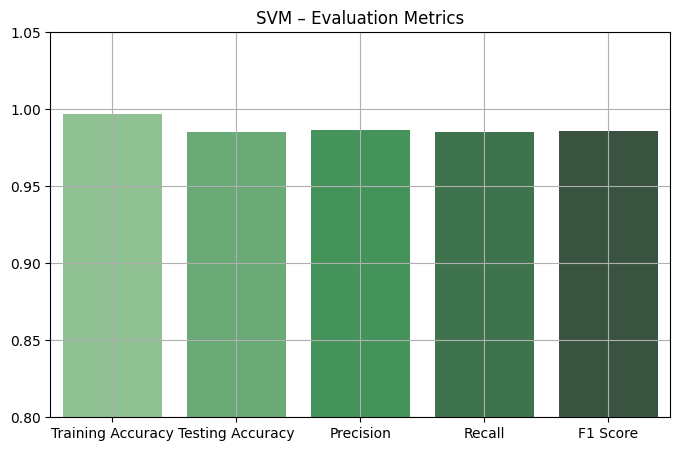

In [27]:
metrics_svm = ['Training Accuracy', 'Testing Accuracy', 'Precision', 'Recall', 'F1 Score']
values_svm  = [train_accuracy_svm, accuracy_svm, precision_svm, recall_svm, f1_svm]

plt.figure(figsize=(8, 5))
sns.barplot(x=metrics_svm, y=values_svm, palette='Greens_d')
plt.title('SVM – Evaluation Metrics')
plt.ylim(0.8, 1.05); plt.grid(True)
plt.show()


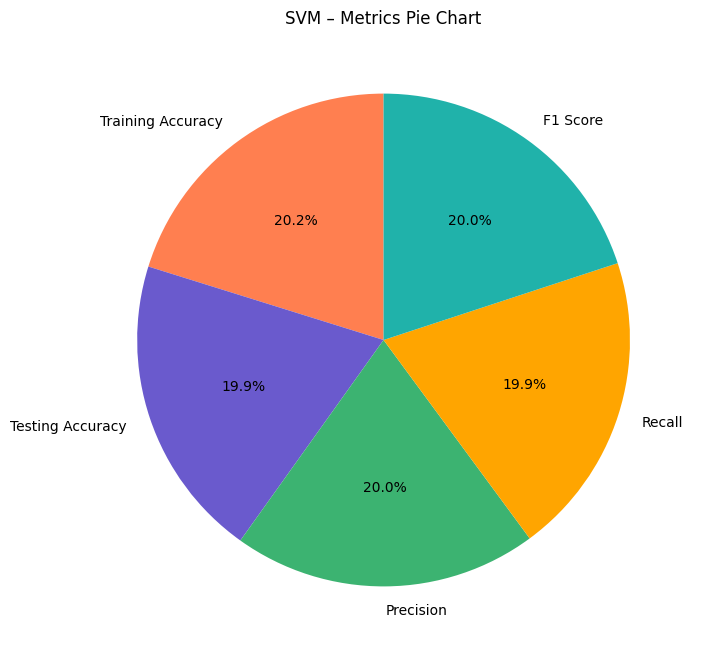

In [28]:
plt.figure(figsize=(8, 8))
colors_svm = ['#FF7F50','#6A5ACD','#3CB371','#FFA500','#20B2AA']
plt.pie(values_svm, labels=metrics_svm, autopct='%1.1f%%', startangle=90, colors=colors_svm)
plt.title('SVM – Metrics Pie Chart')
plt.show()


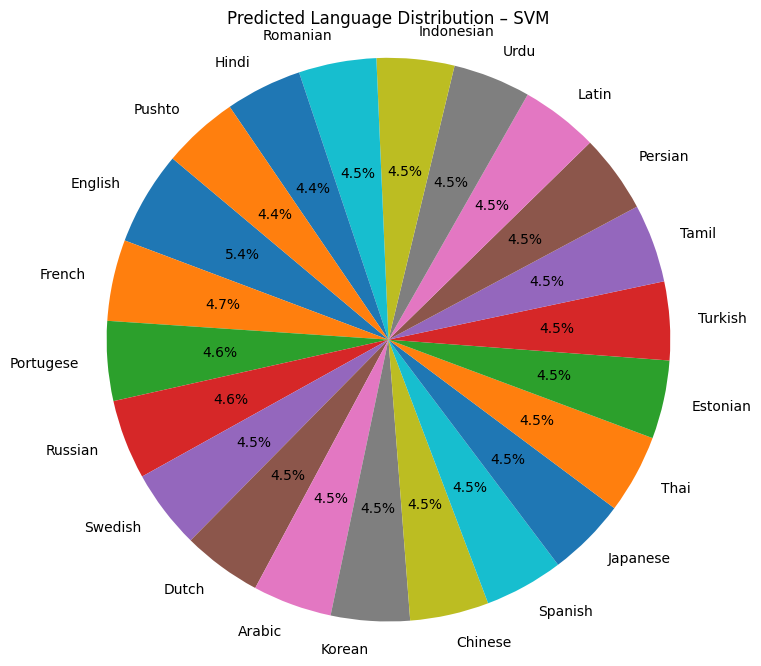

In [29]:
plt.figure(figsize=(8, 8))
pred_counts_svm = pd.Series(y_pred_svm).value_counts()
plt.pie(pred_counts_svm, labels=pred_counts_svm.index, autopct='%1.1f%%', startangle=140)
plt.title('Predicted Language Distribution – SVM')
plt.axis('equal')
plt.show()


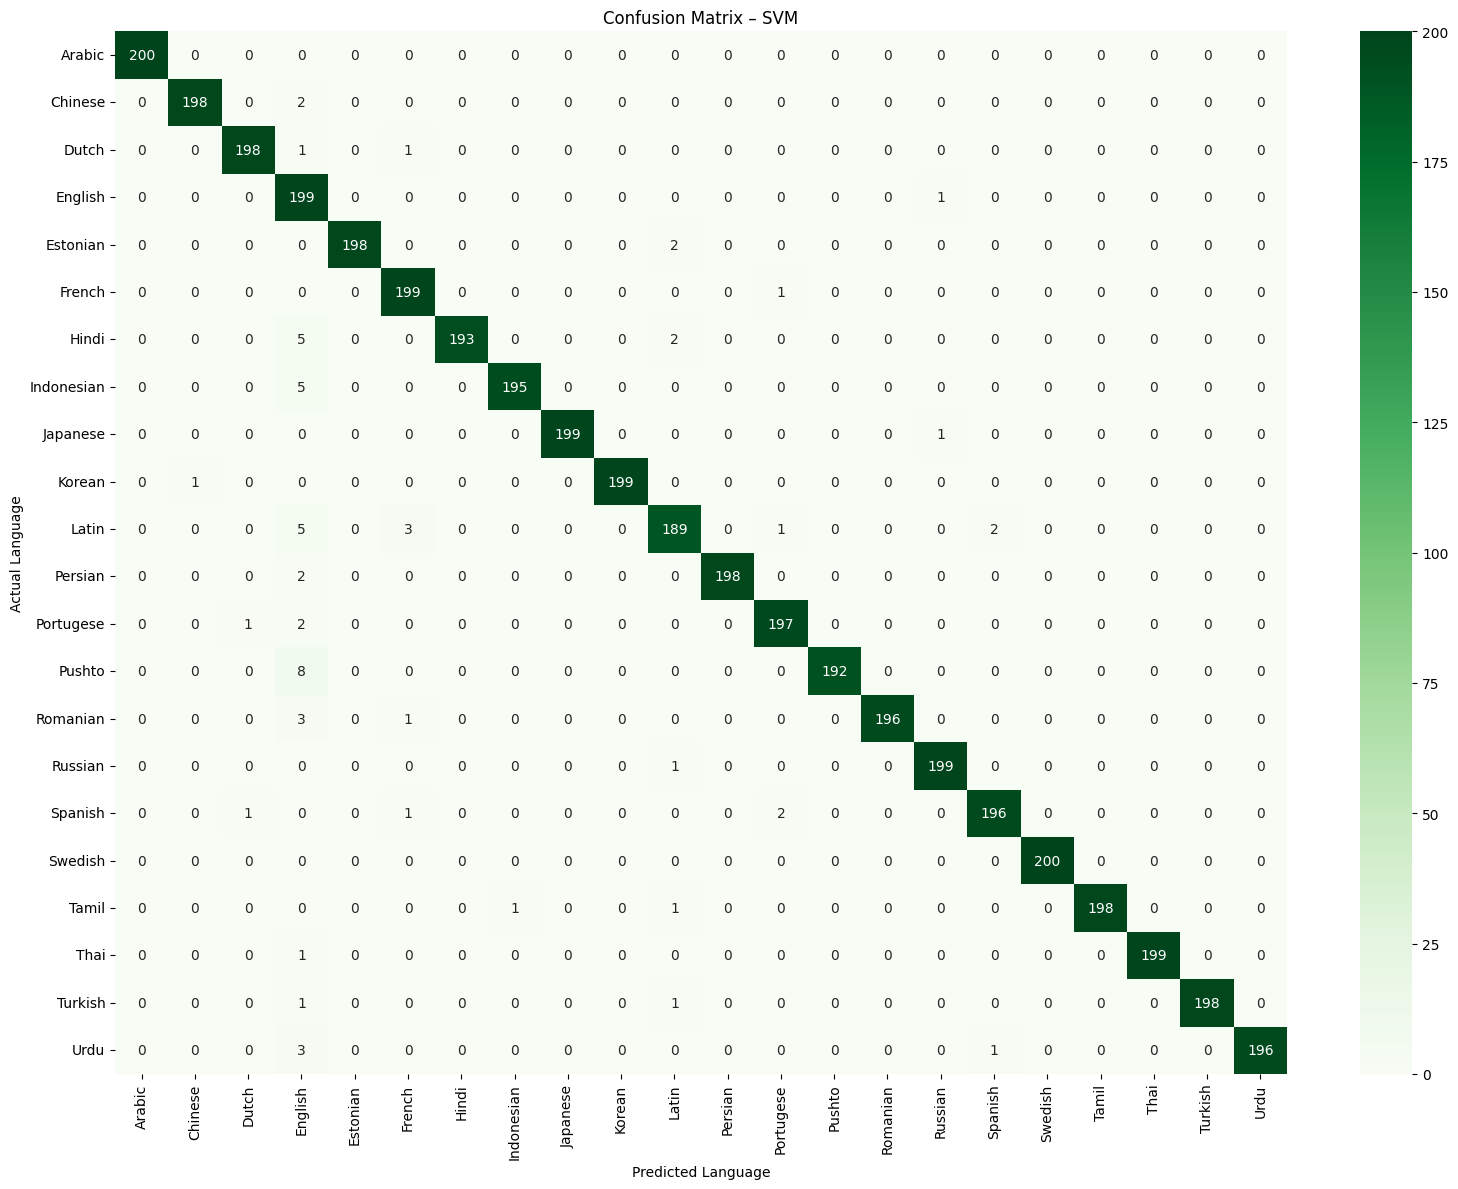

In [30]:
labels_sorted = sorted(y.unique())
cm_svm = confusion_matrix(y_test, y_pred_svm, labels=labels_sorted)
plt.figure(figsize=(16, 12))
sns.heatmap(cm_svm, annot=True, fmt='d', cmap='Greens',
            xticklabels=labels_sorted, yticklabels=labels_sorted)
plt.title('Confusion Matrix – SVM')
plt.xlabel('Predicted Language'); plt.ylabel('Actual Language')
plt.xticks(rotation=90); plt.yticks(rotation=0)
plt.tight_layout(); plt.show()


In [31]:
def predict_language_svm(input_text):
    cleaned_text = clean_text(input_text)
    input_vector = tfidf_vectorizer.transform([cleaned_text])
    prediction = svm_model.predict(input_vector)[0]
    print("\nInput Text:", input_text)
    print("Predicted Language (SVM):", prediction)

while True:
    user_input = input("\n[SVM] Enter a sentence to detect its language (type 'exit' to stop): ")
    if user_input.lower() == 'exit':
        print("Exiting SVM testing.")
        break
    predict_language_svm(user_input)



[SVM] Enter a sentence to detect its language (type 'exit' to stop):  என் பெயர் அபிஷேக்



Input Text: என் பெயர் அபிஷேக்
Predicted Language (SVM): Tamil



[SVM] Enter a sentence to detect its language (type 'exit' to stop):  exit


Exiting SVM testing.


## Random Forest Model

In [32]:
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train_rf, y_train)

y_pred_train_rf = rf_model.predict(X_train_rf)
print(y_pred_train_rf)
y_pred_rf       = rf_model.predict(X_test_rf)
print(y_pred_rf  )
train_accuracy_rf = accuracy_score(y_train, y_pred_train_rf)
accuracy_rf       = accuracy_score(y_test,  y_pred_rf)
precision_rf      = precision_score(y_test, y_pred_rf, average='macro', zero_division=1)
recall_rf         = recall_score(y_test,    y_pred_rf, average='macro', zero_division=1)
f1_rf             = f1_score(y_test,        y_pred_rf, average='macro', zero_division=1)

print("Training Accuracy:", train_accuracy_rf)
print("Test Accuracy    :", accuracy_rf)
print("Precision        :", precision_rf)
print("Recall           :", recall_rf)
print("F1 Score         :", f1_rf)


['Romanian' 'Spanish' 'Spanish' ... 'Russian' 'Portugese' 'Russian']
['Persian' 'Spanish' 'Tamil' ... 'Dutch' 'Latin' 'Latin']
Training Accuracy: 0.951590909090909
Test Accuracy    : 0.9268181818181818
Precision        : 0.9442844126003429
Recall           : 0.9268181818181819
F1 Score         : 0.9247544566509504


In [33]:
print(classification_report(y_test, y_pred_rf))

              precision    recall  f1-score   support

      Arabic       1.00      0.98      0.99       200
     Chinese       0.71      0.20      0.31       200
       Dutch       0.99      0.98      0.99       200
     English       0.83      0.96      0.89       200
    Estonian       0.97      0.94      0.96       200
      French       0.97      0.98      0.98       200
       Hindi       1.00      0.96      0.98       200
  Indonesian       1.00      0.95      0.98       200
    Japanese       0.45      0.93      0.61       200
      Korean       0.98      0.86      0.91       200
       Latin       0.95      0.94      0.94       200
     Persian       0.99      0.98      0.99       200
   Portugese       0.97      0.97      0.97       200
      Pushto       0.99      0.96      0.98       200
    Romanian       0.98      0.98      0.98       200
     Russian       0.99      0.91      0.95       200
     Spanish       0.99      0.97      0.98       200
     Swedish       1.00    

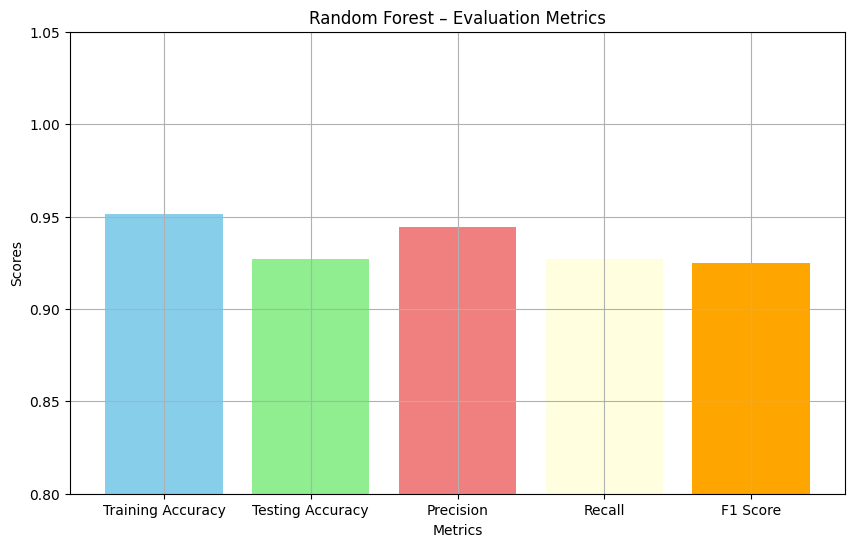

In [34]:
metrics_rf = ['Training Accuracy', 'Testing Accuracy', 'Precision', 'Recall', 'F1 Score']
values_rf  = [train_accuracy_rf, accuracy_rf, precision_rf, recall_rf, f1_rf]

plt.figure(figsize=(10, 6))
plt.bar(metrics_rf, values_rf, color=['skyblue','lightgreen','lightcoral','lightyellow','orange'])
plt.title('Random Forest – Evaluation Metrics')
plt.ylabel('Scores'); plt.xlabel('Metrics')
plt.ylim(0.8, 1.05); plt.grid(True)
plt.show()


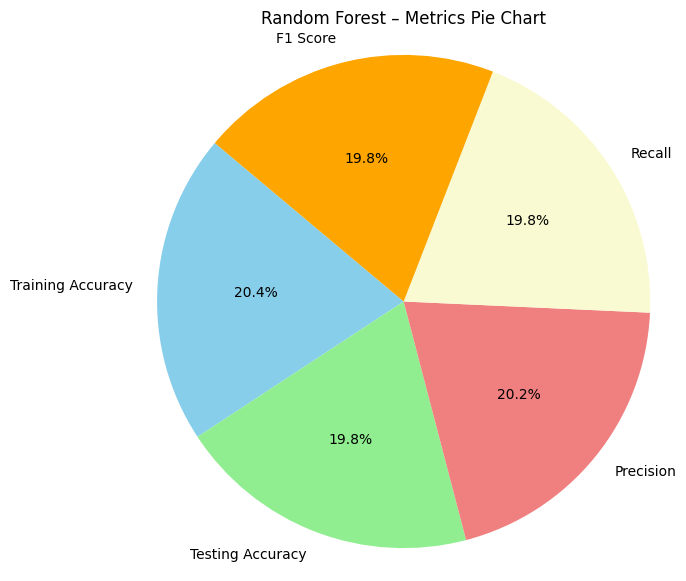

In [35]:
plt.figure(figsize=(7, 7))
plt.pie(values_rf, labels=metrics_rf, autopct='%1.1f%%',
        colors=['skyblue','lightgreen','lightcoral','lightgoldenrodyellow','orange'], startangle=140)
plt.title('Random Forest – Metrics Pie Chart')
plt.axis('equal')
plt.show()


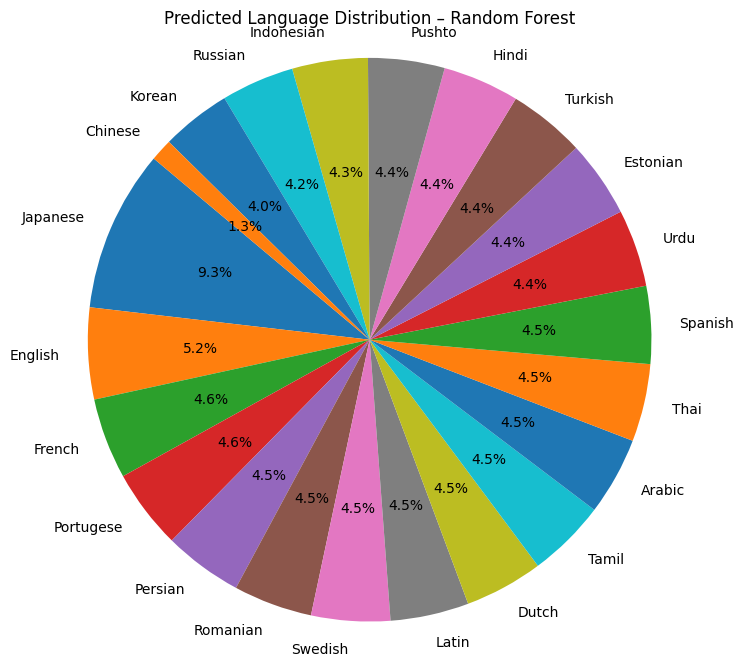

In [36]:
plt.figure(figsize=(8, 8))
pred_counts_rf = pd.Series(y_pred_rf).value_counts()
plt.pie(pred_counts_rf, labels=pred_counts_rf.index, autopct='%1.1f%%', startangle=140)
plt.title('Predicted Language Distribution – Random Forest')
plt.axis('equal')
plt.show()


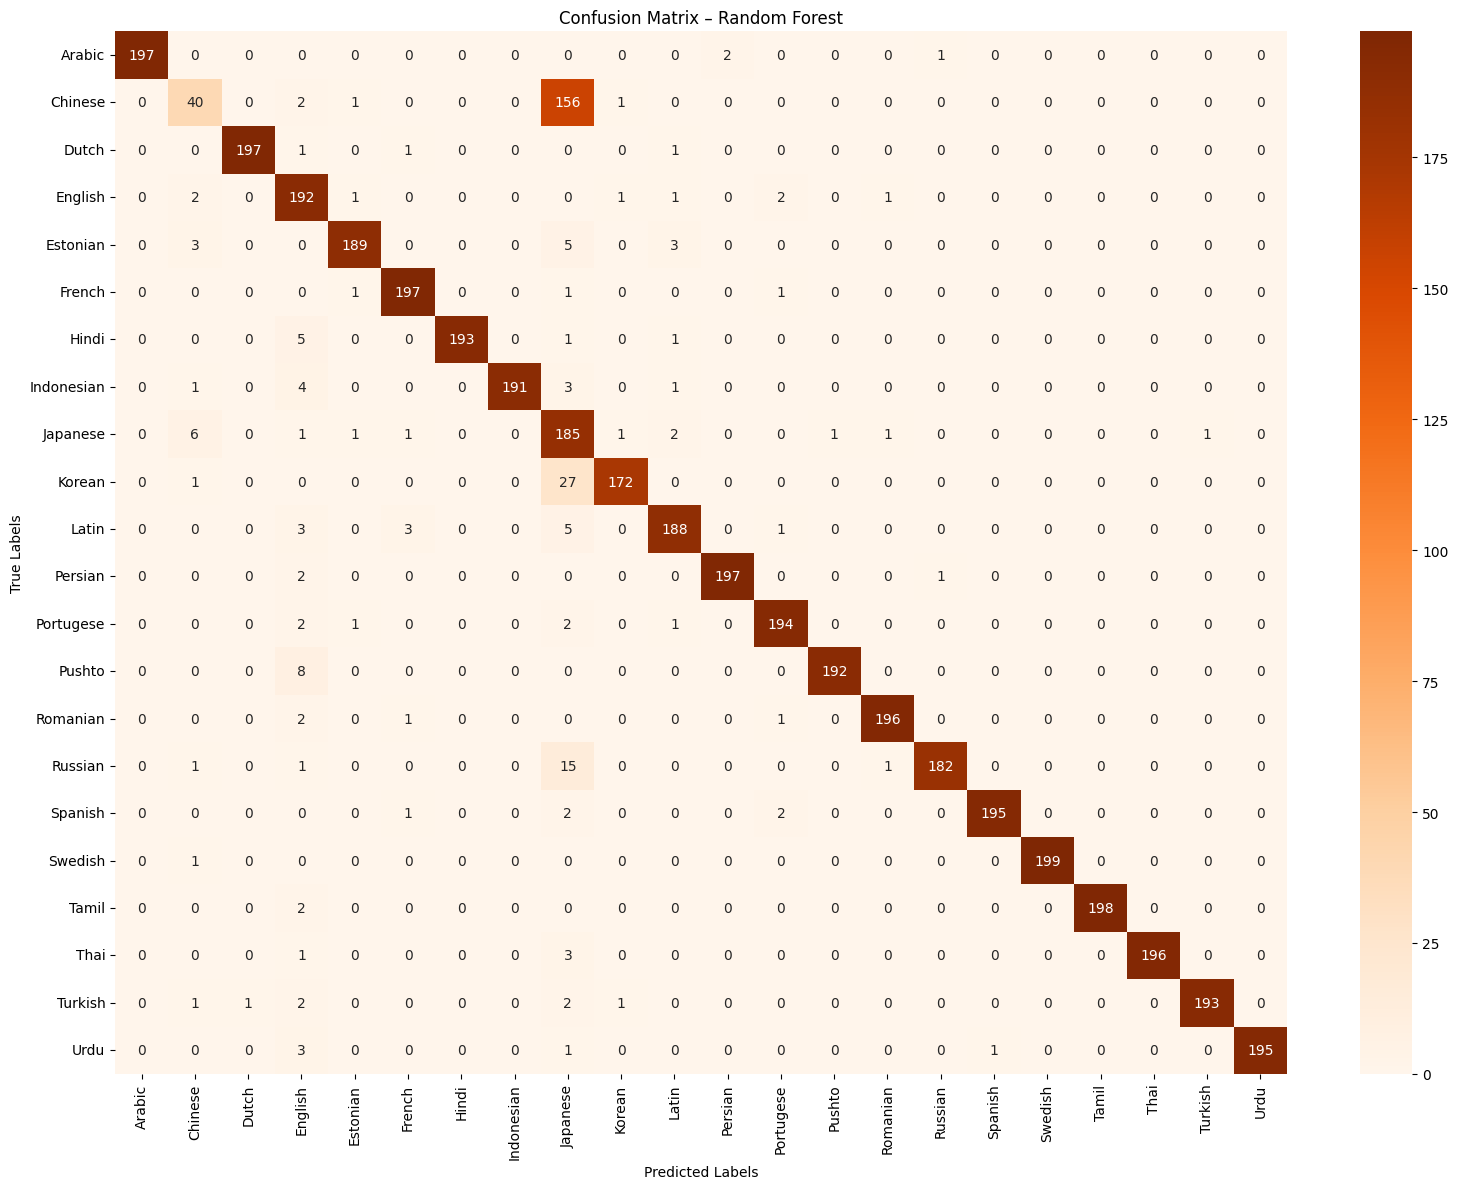

In [37]:
cm_rf = confusion_matrix(y_test, y_pred_rf, labels=label_encoder.classes_)
plt.figure(figsize=(16, 12))
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Oranges',
            xticklabels=label_encoder.classes_,
            yticklabels=label_encoder.classes_)
plt.title('Confusion Matrix – Random Forest')
plt.xlabel('Predicted Labels'); plt.ylabel('True Labels')
plt.xticks(rotation=90); plt.yticks(rotation=0)
plt.tight_layout(); plt.show()


In [38]:
def predict_language_random_forest(input_text):
    cleaned_text = clean_text(input_text)
    input_vector = tfidf_rf.transform([cleaned_text])
    prediction = rf_model.predict(input_vector)[0]
    print("\nInput Text:", input_text)
    print("Predicted Language (Random Forest):", prediction)

while True:
    user_input = input("\n[Random Forest] Enter a sentence to detect its language (type 'exit' to stop): ")
    if user_input.lower() == 'exit':
        print("Exiting Random Forest testing.")
        break
    predict_language_random_forest(user_input)



[Random Forest] Enter a sentence to detect its language (type 'exit' to stop):  私の名前はアビシェクです



Input Text: 私の名前はアビシェクです
Predicted Language (Random Forest): Japanese



[Random Forest] Enter a sentence to detect its language (type 'exit' to stop):  exit


Exiting Random Forest testing.


## Model Comparison

In [39]:
comparison = pd.DataFrame({
    'Model':            ['Naive Bayes', 'Logistic Regression', 'SVM', 'Random Forest'],
    'Train Accuracy':   [train_accuracy_nb, train_accuracy_lr, train_accuracy_svm, train_accuracy_rf],
    'Test Accuracy':    [accuracy_nb,       accuracy_lr,       accuracy_svm,       accuracy_rf],
    'Precision':        [precision_nb,      precision_lr,      precision_svm,      precision_rf],
    'Recall':           [recall_nb,         recall_lr,         recall_svm,         recall_rf],
    'F1 Score':         [f1_nb,             f1_lr,             f1_svm,             f1_rf],
})
print(comparison.to_string(index=False))


              Model  Train Accuracy  Test Accuracy  Precision   Recall  F1 Score
        Naive Bayes        0.984375       0.942727   0.957929 0.942727  0.942445
Logistic Regression        0.984545       0.982045   0.983811 0.982045  0.982467
                SVM        0.997159       0.985455   0.986801 0.985455  0.985765
      Random Forest        0.951591       0.926818   0.944284 0.926818  0.924754


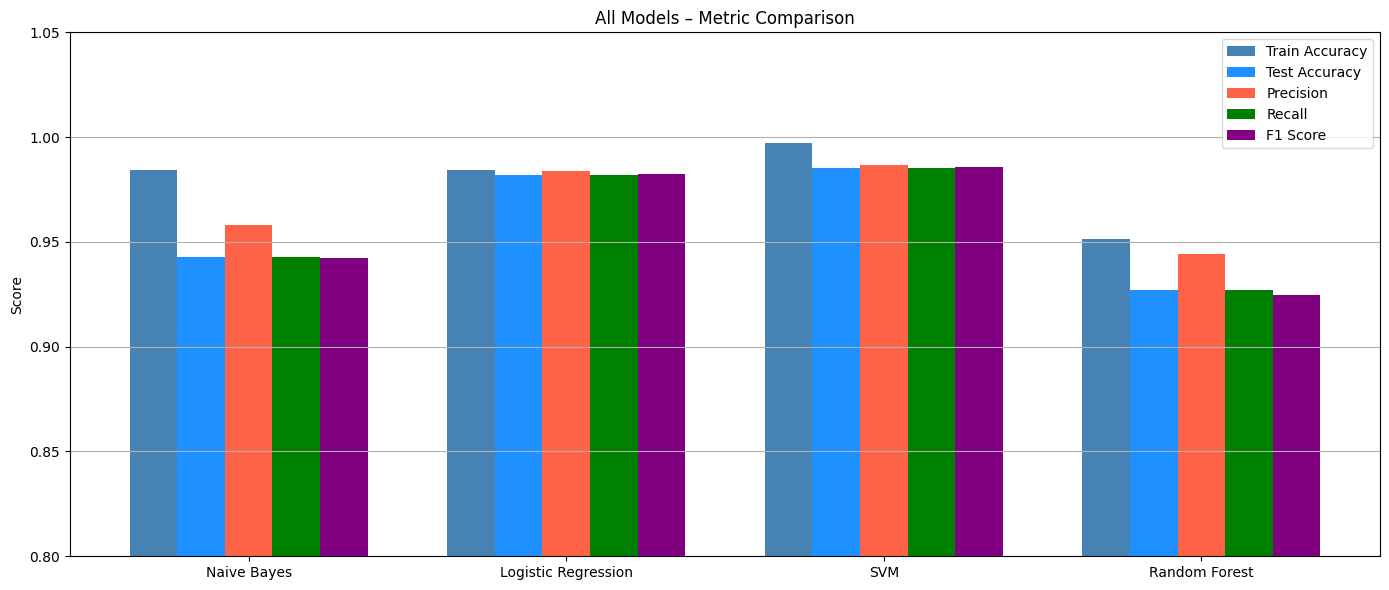

In [40]:
x = np.arange(4)
width = 0.15
model_names = ['Naive Bayes', 'Logistic Regression', 'SVM', 'Random Forest']

train_accs = [train_accuracy_nb, train_accuracy_lr, train_accuracy_svm, train_accuracy_rf]
test_accs  = [accuracy_nb,       accuracy_lr,       accuracy_svm,       accuracy_rf]
precisions = [precision_nb,      precision_lr,      precision_svm,      precision_rf]
recalls    = [recall_nb,         recall_lr,         recall_svm,         recall_rf]
f1_scores  = [f1_nb,             f1_lr,             f1_svm,             f1_rf]

fig, ax = plt.subplots(figsize=(14, 6))
ax.bar(x - 2*width, train_accs, width, label='Train Accuracy', color='steelblue')
ax.bar(x - width,   test_accs,  width, label='Test Accuracy',  color='dodgerblue')
ax.bar(x,           precisions, width, label='Precision',       color='tomato')
ax.bar(x + width,   recalls,    width, label='Recall',          color='green')
ax.bar(x + 2*width, f1_scores,  width, label='F1 Score',        color='purple')

ax.set_xticks(x); ax.set_xticklabels(model_names)
ax.set_ylim(0.8, 1.05); ax.set_ylabel('Score')
ax.set_title('All Models – Metric Comparison')
ax.legend(); ax.grid(True, axis='y')
plt.tight_layout(); plt.show()


## Final Conclusions of the Project

1.  Best Overall Model – SVM (Support Vector Machine):  The SVM model achieved the highest test accuracy (~98.6%) among all models.  
- It uses character-level TF-IDF n-gram features (unigrams to trigrams), which capture script and morphological patterns extremely well.  
- The small gap between training accuracy (~99.7%) and test accuracy confirms that the model is powerful yet still generalises well to unseen data.  
- SVM is highly effective in NLP tasks because it can find optimal decision boundaries in high-dimensional feature spaces.

2. Best Balanced Model – Logistic Regression:  Logistic Regression achieved a training accuracy of ~98.4% and a test accuracy of ~98.2%, which are the closest to each other among all models.  
- The minimal gap between training and testing accuracy shows that the model generalises well and avoids overfitting.  
- This balance indicates that Logistic Regression captures important language patterns without memorising the training data, making it a reliable and interpretable choice.

3. Moderate Performer – Multinomial Naive Bayes: Naive Bayes achieved a training accuracy of ~98.4% but a slightly lower test accuracy of ~94.3%, indicating a moderate degree of overfitting.  
- Despite this, it performs well and is extremely fast to train, making it a strong baseline model for language identification tasks.  
- Its performance is slightly limited because it uses Bag-of-Words (word-level) features and assumes feature independence.

4. Most Stable but Lower Accuracy – Random Forest:  Random Forest achieved a training accuracy of ~95.1% and a test accuracy of ~92.8%, which are consistent and close to each other.  
- The small gap indicates the model does not overfit the training data.  
- However, its overall accuracy is noticeably lower than SVM and Logistic Regression because word-level TF-IDF (max 1000 features) does not capture the richness of character-level patterns that distinguish languages.  
- Increasing `max_features` or using character n-grams could improve its performance further.


In [41]:
import pickle

# Save the TF-IDF vectorizer (used by SVM — highest accuracy model)
with open('tfidf_vectorizer.pkl', 'wb') as f:
    pickle.dump(tfidf_vectorizer, f)

# Save the trained SVM model
with open('svm_model.pkl', 'wb') as f:
    pickle.dump(svm_model, f)

print("tfidf_vectorizer.pkl  — saved successfully")
print("svm_model.pkl         — saved successfully")
print("\nNow place both .pkl files in the same folder as app.py")

tfidf_vectorizer.pkl  — saved successfully
svm_model.pkl         — saved successfully

Now place both .pkl files in the same folder as app.py
